# GNN for Graph Level Predictions about Knots (Volume)

Juan José H. Beltrán

In [2]:
# Requirements:
# !pip install numpy pandas scikit-learn torch torch_geometric matplotlib

In [3]:
import dataset
import torch
import numpy as np
import random
from torch_geometric.loader import DataLoader
from settings import *

### Asegurar Reproduciilidad

In [4]:
# Set seed for PyTorch
torch.manual_seed(SEED)

# Set seed for CUDA (if using GPUs)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# Set seed for Python's random module
random.seed(SEED)

# Set seed for NumPy
np.random.seed(SEED)

# Ensure deterministic behavior for PyTorch operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Create Dataset and Dataloader

In [5]:
train_loader, val_loader, deg, knot_dataset = dataset.load()

# Esto debería pasarse a dataset.py
testGeneralisazion = DataLoader(dataset.fetchDataset(TEST_PATH)["dataPoint"], batch_size = BATCH_SIZE)

Dataset consists of  73655 train samples and  18414 test samples
max_degree: 45


### Explore Dataset

Cada dataset contiene una fila por cada grafo. Cada grafo tiene a su vez:
- `x`: Tensor con las features de los nodos. En este caso contiene el grado del nodo (input features: 1).
- `edge_index`: Tensor con la descripción de las aristas del grafo, especificando su origen y destino.
- `edge_atrr`: Tensor con los atributos de cada arista del grafo. En este caso son la "distancia" y si está o no "alternando".
- `y`: Tensor con los labels. En este caso, es un único label para todo el grafo: el invariante a predecir.

In [6]:
knot_dataset = knot_dataset.dataPoint

In [7]:
knot_dataset[0].edge_attr

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Functions and Classes for GNN

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from settings import *

In [9]:
# Import custom GNN models from models.py
from models import PNAKnotNet
from models import GATKnotNet
from models import TransKnotNet

In [10]:
torch.manual_seed(31)
model = PNAKnotNet(deg)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 20, min_lr = 0.00001)

In [11]:
def train(epoch):
    model.train()

    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            if USE_DISTANCE_ATTRIBUTE:
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            else:
                out = model(data.x, data.edge_index, data.edge_attr.reshape(-1, 1), data.batch)

        if LOSS == "abs":
            loss = (out.squeeze() - data.y).abs().mean() # Mean Absolute Error
        elif LOSS == "squared":
            loss = (out.squeeze() - data.y).square().mean() # Mean Squared Error
        elif LOSS == "percentage":
            loss = ((out.squeeze() - data.y) / data.y).abs().mean() # Mean Absolute Percentage Error

        loss.backward()
        total_loss += loss.item() * data.num_graphs
        optimizer.step()

    return total_loss / len(train_loader.dataset)

In [12]:
@torch.no_grad()
def test(loader):
    model.eval()

    total_error = 0
    for data in loader:
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            if USE_DISTANCE_ATTRIBUTE:
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            else:
                out = model(data.x, data.edge_index, data.edge_attr.reshape(-1, 1), data.batch)
        
        if LOSS=="abs":
            total_error += (out.squeeze() - data.y).abs().sum().item()
        elif LOSS=="squared":
            total_error += (out.squeeze() - data.y).square().sum().item()
        elif LOSS == "percentage":
            total_error += ((out.squeeze() - data.y) / data.y).abs().sum().item()
    
    return total_error / len(loader.dataset)

In [13]:
def plot_distribution_of_errors(real, expected):
    plt.figure(figsize=(10, 6))
    plt.grid()
    plt.hist(expected - real, bins = 50)
    plt.title(f"Distribution of errors for {model._get_name()}")
    plt.xlabel("Error")
    plt.ylabel(f"Frecuency")
    # plt.yscale("log")
    # plt.legend()
    plt.vlines(0, 0, 400, "red", "dashed")
    plt.show()

In [14]:
def plot_errors_vs_values(real, expected):
    plt.figure(figsize=(10, 6))
    plt.grid()
    plt.scatter(real, expected - real)
    plt.title(f"Errors vs Expected Values for {model._get_name()}")
    plt.xlabel("Expected value")
    plt.ylabel(f"Error")
    # plt.yscale("log")
    # plt.legend()
    plt.show()

In [15]:
@torch.no_grad()
def evaluate(loader):
    model.eval()

    real = np.array([])
    expected = np.array([])
    for data in loader:
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            if USE_DISTANCE_ATTRIBUTE:
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            else:
                out = model(data.x, data.edge_index, data.edge_attr.reshape(-1, 1), data.batch)
        
        real = np.append(real, data.y)
        expected = np.append(expected, out.squeeze())
    
    # Graph and analize errors
    plot_distribution_of_errors(real, expected)
    plot_errors_vs_values(real, expected)
    
    return real, expected


## Train Model

In [16]:
try_generalization = True

history_train_loss = []
history_val_loss = []
history_gen_loss = []
history_gen_acc = []

for epoch in range(1, 50):
    val_loss = test(val_loader)
    if try_generalization:
        gen_loss = test(testGeneralisazion)
    loss = train(epoch)

    # Append history for plotting later
    history_train_loss.append(loss)
    history_val_loss.append(val_loss)
    if try_generalization:
        history_gen_loss.append(gen_loss)

    scheduler.step(loss)
    if try_generalization:
        print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}, Generalization loss: {gen_loss:.4f}')
    else:
        print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}')

Epoch: 01, Train loss: 4.6609, Val loss: 15.0121, Generalization loss: 10.7081
Epoch: 02, Train loss: 2.4926, Val loss: 2.5961, Generalization loss: 4.5730
Epoch: 03, Train loss: 2.3286, Val loss: 2.5126, Generalization loss: 3.1681
Epoch: 04, Train loss: 2.2212, Val loss: 2.6015, Generalization loss: 2.6420
Epoch: 05, Train loss: 2.1459, Val loss: 2.1553, Generalization loss: 3.5518
Epoch: 06, Train loss: 2.0939, Val loss: 2.1419, Generalization loss: 3.4137
Epoch: 07, Train loss: 2.0472, Val loss: 2.1269, Generalization loss: 3.8038
Epoch: 08, Train loss: 2.0121, Val loss: 2.0704, Generalization loss: 3.5986
Epoch: 09, Train loss: 1.9813, Val loss: 2.0135, Generalization loss: 3.3236
Epoch: 10, Train loss: 1.9590, Val loss: 1.9745, Generalization loss: 3.2539
Epoch: 11, Train loss: 1.9375, Val loss: 1.9875, Generalization loss: 2.8237
Epoch: 12, Train loss: 1.9206, Val loss: 2.0225, Generalization loss: 2.6362
Epoch: 13, Train loss: 1.9051, Val loss: 2.0414, Generalization loss: 2.64

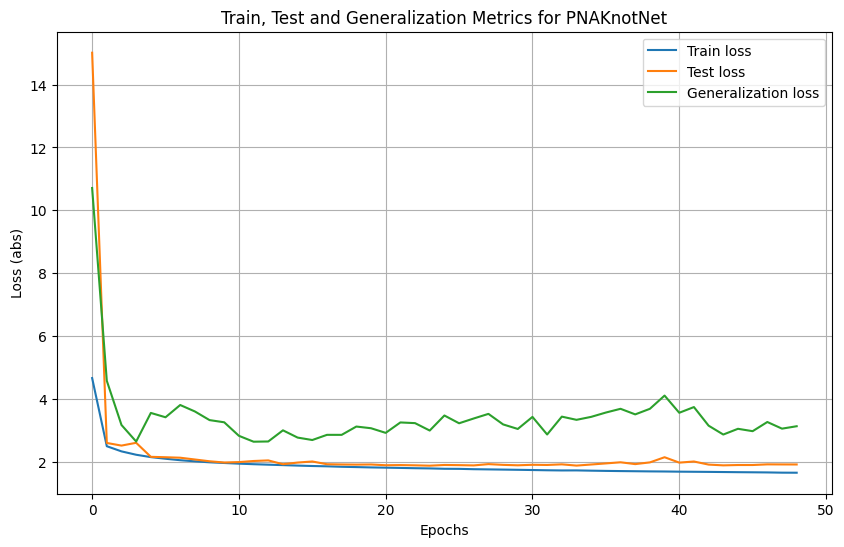

In [17]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Test loss")
if try_generalization:
    plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Train, Test and Generalization Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel(f"Loss ({LOSS})")
plt.legend()
plt.show()

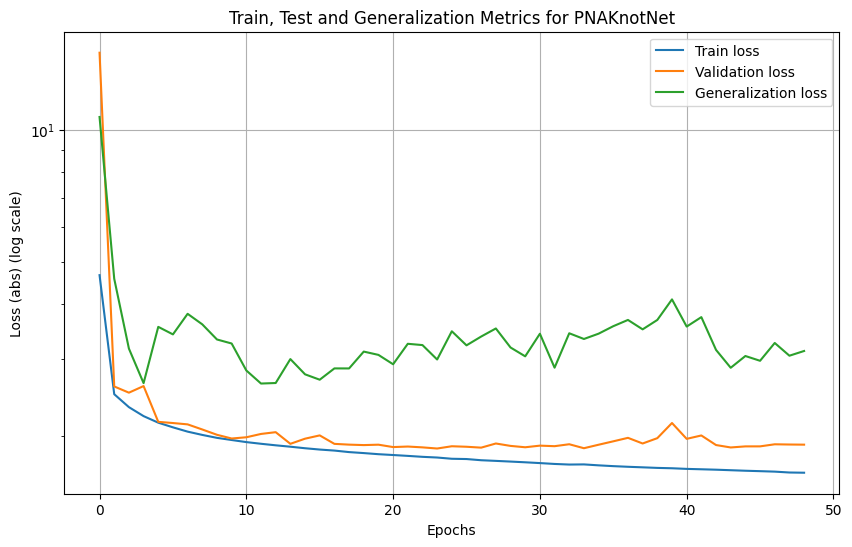

In [18]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
if try_generalization:
    plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Train, Test and Generalization Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel(f"Loss ({LOSS}) (log scale)")
plt.yscale("log")
plt.legend()
plt.show()

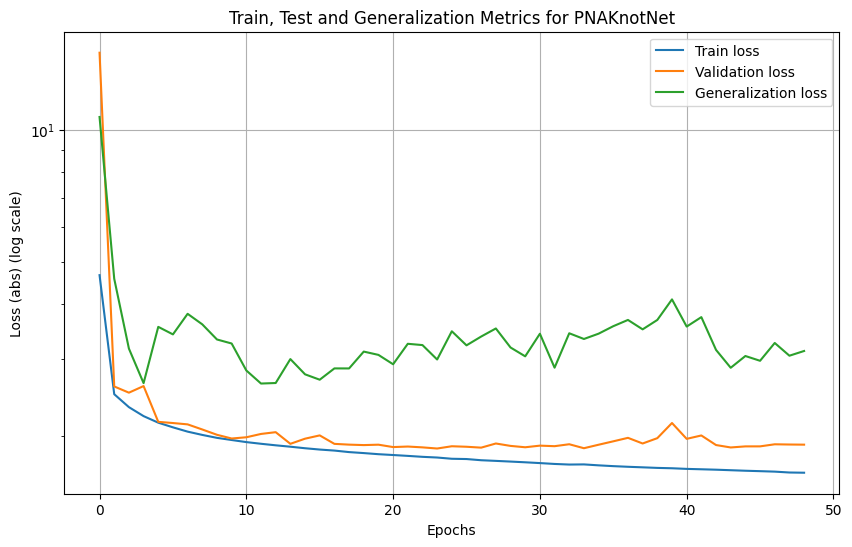

In [19]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss[:50], label = "Train loss")
plt.plot(history_val_loss[:50], label = "Validation loss")
if try_generalization:
    plt.plot(history_gen_loss[:50], label = "Generalization loss")

plt.title(f"Train, Test and Generalization Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel(f"Loss ({LOSS}) (log scale)")
plt.yscale("log")
plt.legend()
plt.show()

In [20]:
# Save the trained model
torch.save(model.state_dict(), f"models/{model._get_name()}_{FEATURE}_{LOSS}_bs{BATCH_SIZE}_add{ADDITIONAL}_distance{USE_DISTANCE_ATTRIBUTE}_B.pt")

## Analize Model

In [33]:
import pandas as pd
import time
results = []

In [31]:
@torch.no_grad()
def just_evaluate(loader):
    model.eval()
    for data in loader:
        out = model(data.x, data.edge_index, data.edge_attr.reshape(-1, 1), data.batch)

In [35]:
inicio = time.time()
just_evaluate(val_loader)
fin = time.time()
print(fin-inicio)

11.329869747161865


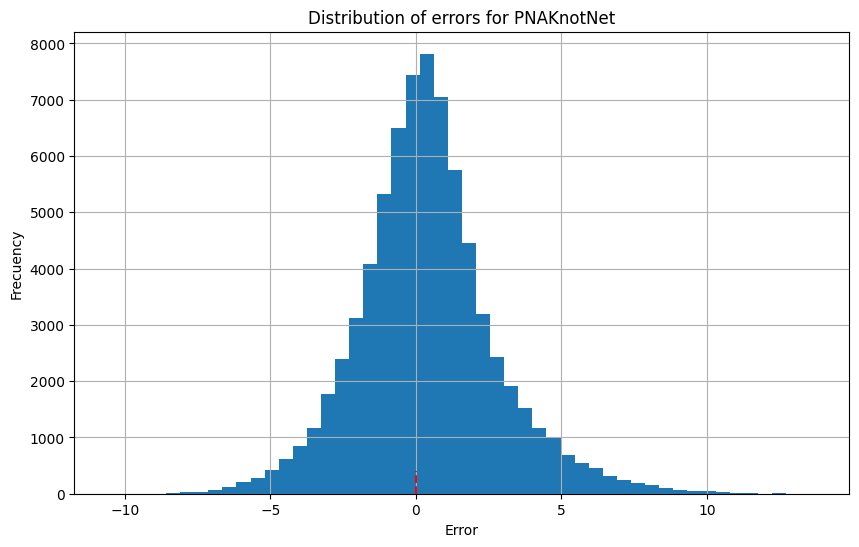

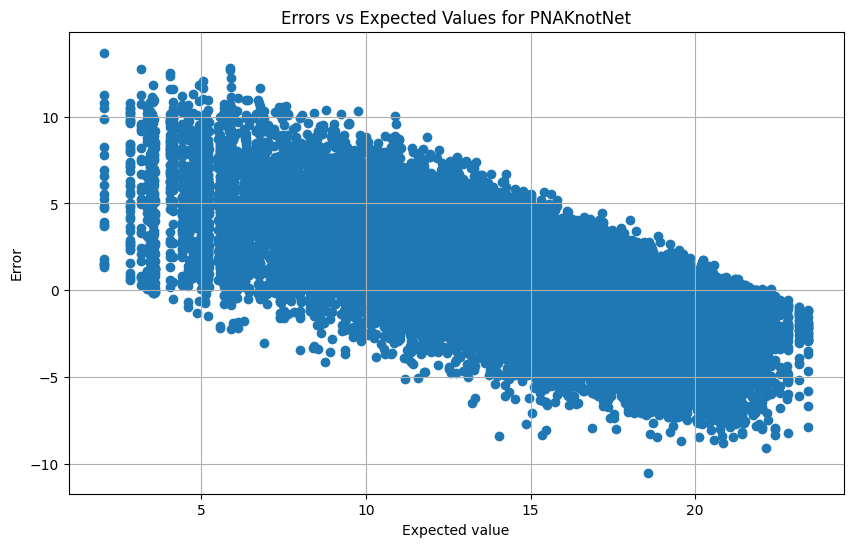

In [ ]:
aux = pd.DataFrame()
aux['real'], aux['expected'] = evaluate(train_loader)
aux['error'] = aux['expected'] - aux['real']
aux['set'] = 'train'
results.append(aux.copy())

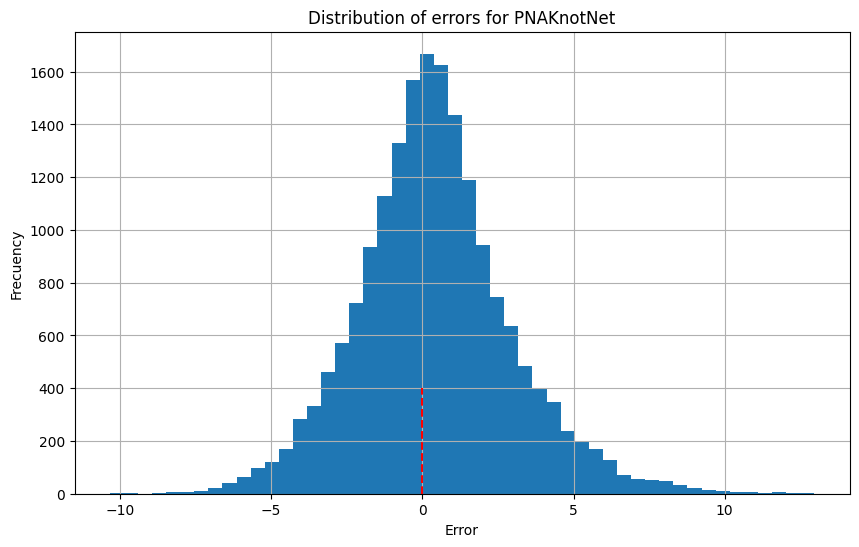

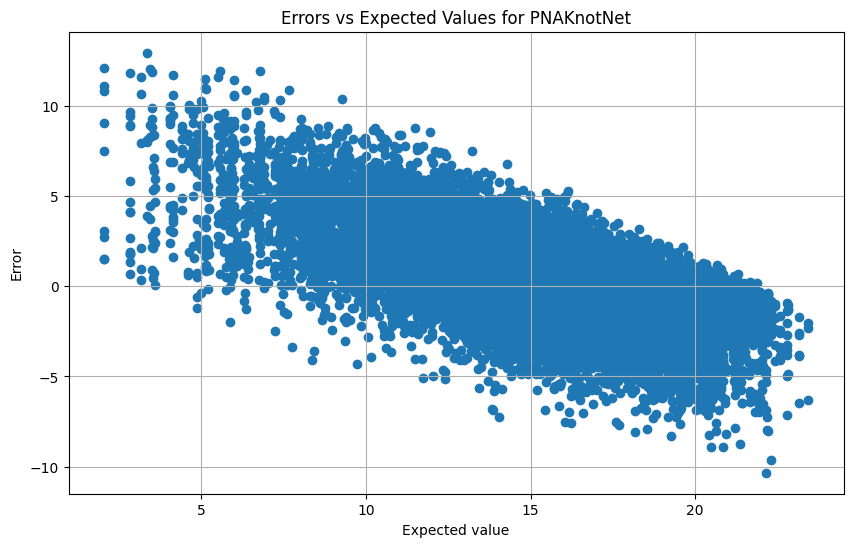

In [23]:
aux = pd.DataFrame()
aux['real'], aux['expected'] = evaluate(val_loader)
aux['error'] = aux['expected'] - aux['real']
aux['set'] = 'test'
results.append(aux.copy())

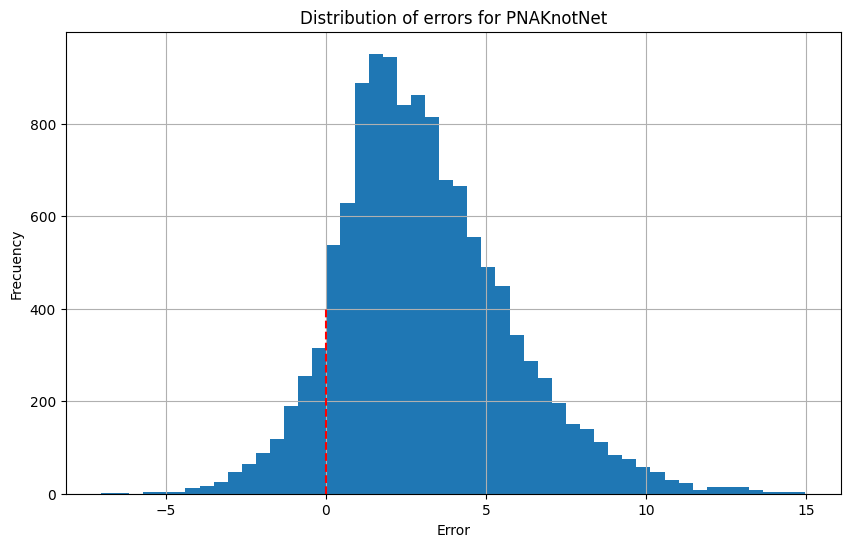

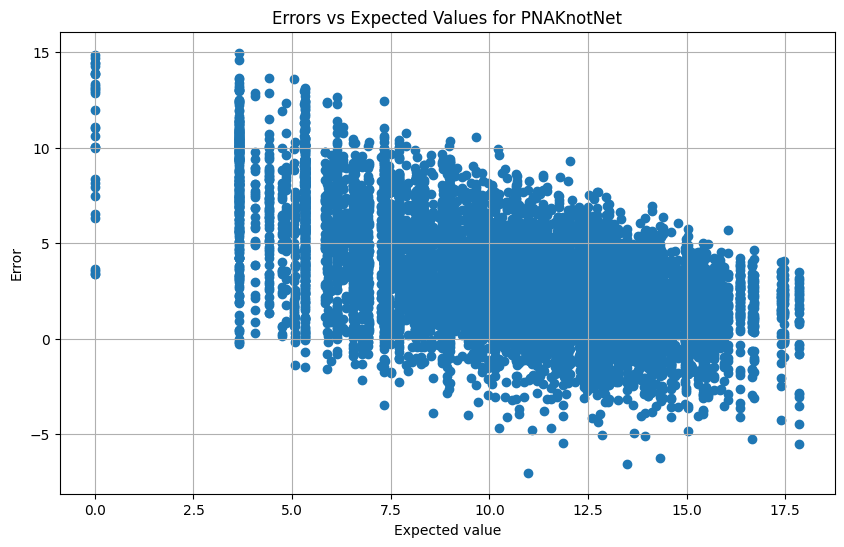

In [24]:
aux = pd.DataFrame()
aux['real'], aux['expected'] = evaluate(testGeneralisazion)
aux['error'] = aux['expected'] - aux['real']
aux['set'] = 'test_gen'
results.append(aux.copy())

In [25]:
pd.concat(results, axis=0, ignore_index=True).to_csv("outputs/results-experimentB.csv", index=False, float_format='%.15f')